# Lab 15

## Section 1: PyTorch 



## Import Torch

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
pip install torch

### Task 1: GPU/Device Agnostic Code
**Goal:** Write code that runs on CPU, CUDA, or MPS (Mac) automatically.


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')


sample_input = torch.randn(1, 10).to(device)
type(sample_input)

Using device: mps


torch.Tensor

In [3]:
sample_input

tensor([[-1.1542,  0.4905,  0.6145, -1.0773, -0.6494,  0.1097, -0.3695,  0.8294,
          1.2324, -1.3036]], device='mps:0')

## Section 2: MNIST Project 
Step 1: What is MNIST & Downloading Data

Concept: MNIST is the "Hello World" of Machine Learning. It contains 70,000 images of handwritten digits (0-9).

The Goal: Teach the computer to look at a grid of pixels and say "That is a 7".

The Data: Each image is grayscale and exactly 28×28


In [26]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [ ]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# transform=ToTensor() converts the image (0-255) to a Torch Tensor (0.0-1.0)

100%|██████████████████████████| 26421880/26421880 [00:04<00:00, 6084673.68it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|█████████████████████████████████| 29515/29515 [00:00<00:00, 158011.68it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|████████████████████████████| 4422102/4422102 [00:01<00:00, 2880115.75it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████████████████████████████| 5148/5148 [00:00<00:00, 3183762.46it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [29]:
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## Visualizing One Image & Understanding Shapes

In [30]:
len(training_data)

60000

In [31]:
len(test_data)

10000

In [32]:
img, label = training_data[100]

In [33]:
img.shape

torch.Size([1, 28, 28])

In [34]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0039, 0.0000, 0.0000, 0.0706, 0.4196, 0.4667, 0.4039,
          0.0353, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.3882, 0.6078, 0.4431, 0.2392, 0.4627,
          0.6784, 0.4588, 0.0000, 0.0000, 0.0118, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0039, 0.0000, 0.4314, 0.5333, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.6549, 0.6235, 0.0000, 0.0000, 0.0078, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0235,
          0.0000, 0.2824, 0.5765, 0.0000, 0.0000, 0.0196, 0.0000, 0.0078,
          0.0000, 0.0000, 0.6824, 0.4627, 0.0000, 0.0196,

In [35]:
img.squeeze().shape

torch.Size([28, 28])

## Display one Image in MatplotLib

In [36]:
import matplotlib.pyplot as plt

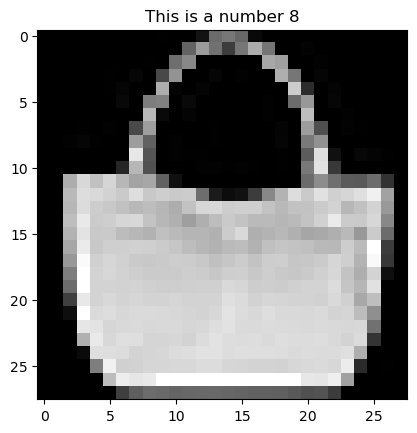

In [37]:
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"This is a number {label}")
plt.show()

# Calculation for the Input Layer

Concept: We are building a Linear (Feed-Forward) Network,

A Linear Layer consists of neurons in a single vertical line.

Our image is a square grid (28×28).

The Division: We must "cut" the image row by row and stack them into one long line.

The Calculation:

Height×Width=Total Input Features
28×28=784
So, our Input Layer must have 784 neurons.

In [ ]:
img, label = training_data[1]

In [ ]:
img.squeeze().shape

torch.Size([28, 28])

## The Architecture (1 Input, 1 Hidden, 1 Output
The Concept: We will build the simplest standard network.

Input Layer (784): Receives the pixels.

Hidden Layer (128): The "brain" that learns shapes (loops, lines). We pick 128 because it's enough to learn but not too big.

Output Layer (10): The final decision. We have 10 digits (0-9), so we need 10 output scores.

In [50]:
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        
        self.layers = nn.Sequential(
            nn.Linear(784, 128), 
            nn.ReLU(),# Activation 
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model = SimpleNet()
print(model)

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=500, bias=True)
    (1): ReLU()
    (2): Linear(in_features=500, out_features=10, bias=True)
  )
)


## Understanding Batch Size (The Stack)

The Concept: Think of the model like a teacher grading exams.

Batch Size = 1: The teacher grades 1 exam, updates the grade book, then picks up the next exam. (Too slow).

Batch Size = 64: The teacher picks up a stack of 64 exams, grades them all at once, and updates the grade book one time for the whole stack. (Much faster).

We use DataLoader to create these "stacks" for us.

In [51]:
from torch.utils.data import DataLoader

# Create stacks
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

print(len(train_loader),"--",len(test_loader))


938 -- 157


## The Training Loop

In [52]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [53]:
def train(num_epochs):
    model.train()
    
    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")
        
        for batch_No, (data, target) in enumerate(train_loader):
            
            output = model(data)
            
            loss = loss_fn(output, target)
            
            # Backpropagation
            optimizer.zero_grad()  # Clear old calculations
            loss.backward()        # Calculate gradients
            optimizer.step()       # Update weights
            
            if batch_No % 100 == 0:
                print(f"Batch {batch_No}: Loss = {loss.item():.4f}")
        
        print(f"Epoch {epoch + 1} completed!")

# Run training

In [54]:
train(5)


--- Epoch 1/5 ---
Batch 0: Loss = 2.2923
Batch 100: Loss = 0.5067
Batch 200: Loss = 0.5063
Batch 300: Loss = 0.5732
Batch 400: Loss = 0.6466
Batch 500: Loss = 0.3282
Batch 600: Loss = 0.3854
Batch 700: Loss = 0.5990
Batch 800: Loss = 0.3982
Batch 900: Loss = 0.3184
Epoch 1 completed!

--- Epoch 2/5 ---
Batch 0: Loss = 0.3251
Batch 100: Loss = 0.4118
Batch 200: Loss = 0.3879
Batch 300: Loss = 0.3052
Batch 400: Loss = 0.3008
Batch 500: Loss = 0.3142
Batch 600: Loss = 0.3722
Batch 700: Loss = 0.5828
Batch 800: Loss = 0.3104
Batch 900: Loss = 0.4490
Epoch 2 completed!

--- Epoch 3/5 ---
Batch 0: Loss = 0.2823
Batch 100: Loss = 0.4977
Batch 200: Loss = 0.5310
Batch 300: Loss = 0.3644
Batch 400: Loss = 0.2713
Batch 500: Loss = 0.4570
Batch 600: Loss = 0.4461
Batch 700: Loss = 0.2729
Batch 800: Loss = 0.3673
Batch 900: Loss = 0.3490
Epoch 3 completed!

--- Epoch 4/5 ---
Batch 0: Loss = 0.3769
Batch 100: Loss = 0.2926
Batch 200: Loss = 0.3210
Batch 300: Loss = 0.1927
Batch 400: Loss = 0.3680


In [55]:
def test():
    model.eval() 
    correct = 0
    
    with torch.no_grad(): 
        for data, target in test_loader:
            output = model(data)
            
            prediction = output.argmax(dim=1) 
            
            correct += (prediction == target).sum().item()

    accuracy = correct / len(test_loader.dataset)
    print(f"Test Accuracy: {accuracy:.1%}")

test()

Test Accuracy: 85.7%


In [57]:
def test():
    model.eval() 
    correct = 0
    
    with torch.no_grad(): 
        for data, target in train_loader:
            output = model(data)
            
            prediction = output.argmax(dim=1) 
            
            correct += (prediction == target).sum().item()

    accuracy = correct / len(train_loader.dataset)
    print(f"Test Accuracy: {accuracy:.1%}")

test()

Test Accuracy: 87.8%
